In [1]:
from datasets import load_dataset
local_dir = "./data"

dataset = load_dataset("gfissore/arxiv-abstracts-2021", cache_dir=local_dir)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'abstract', 'report-no', 'categories', 'versions'],
        num_rows: 1999486
    })
})


In [2]:
dataset.set_format(type="pandas")
df = dataset['train'][:]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999486 entries, 0 to 1999485
Data columns (total 11 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   id           object
 1   submitter    object
 2   authors      object
 3   title        object
 4   comments     object
 5   journal-ref  object
 6   doi          object
 7   abstract     object
 8   report-no    object
 9   categories   object
 10  versions     object
dtypes: object(11)
memory usage: 167.8+ MB


In [4]:
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,A fully differential calculation in perturba...,ANL-HEP-PR-07-12,[hep-ph],"[v1, v2]"
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,None,None,"We describe a new algorithm, the $(k,\ell)$-...",None,[math.CO cs.CG],"[v1, v2]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",None,None,The evolution of Earth-Moon system is descri...,None,[physics.gen-ph],"[v1, v2, v3]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,None,None,We show that a determinant of Stirling cycle...,None,[math.CO],[v1]
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,None,"Illinois J. Math. 52 (2008) no.2, 681-689",None,In this paper we show how to compute the $\L...,None,[math.CA math.FA],[v1]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
def get_year_from_id(arxiv_id):
    try:
        arxiv_id_str = str(arxiv_id)
        
        # For Old format, like 'hep-ph/9711200' -> '97' -> 1997
        if '/' in arxiv_id_str:
            yy_str = arxiv_id_str.split('/')[1][:2]
        else:
        # For New format, numeric (considering leading zero loss)
            # take the part before the dot, if not enough 4 digits, pad with zeros
            # e.g. '704.0001' -> '704' -> '0704' ->  '07' -> 2007
            prefix = arxiv_id_str.split('.')[0]
            yy_str = prefix.zfill(4)[:2]
            
        yy_int = int(yy_str)
        
        # Boundary: 00-21 --- 2000-2021, others --- 19XX
        if 0 <= yy_int <= 21:
            return 2000 + yy_int
        else:
            return 1900 + yy_int
    except:
        return np.nan



In [8]:
df['year'] = df['id'].apply(get_year_from_id)

#  outliers removal  + convert to integers
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

print(f"count_num: {len(df)}")
print(f"range: {df['year'].min()} - {df['year'].max()}")

count_num: 1999486
range: 1991 - 2021


year
1991       306
1992      3261
1993      6741
1994     10088
1995     13002
1996     15865
1997     19624
1998     24167
1999     27695
2000     30587
2001     33197
2002     36102
2003     39409
2004     43708
2005     46827
2006     50224
2007     55638
2008     58915
2009     64046
2010     70125
2011     76574
2012     84603
2013     92641
2014     97517
2015    105280
2016    113380
2017    123523
2018    140616
2019    155866
2020    178329
2021    181630
Name: count, dtype: int64


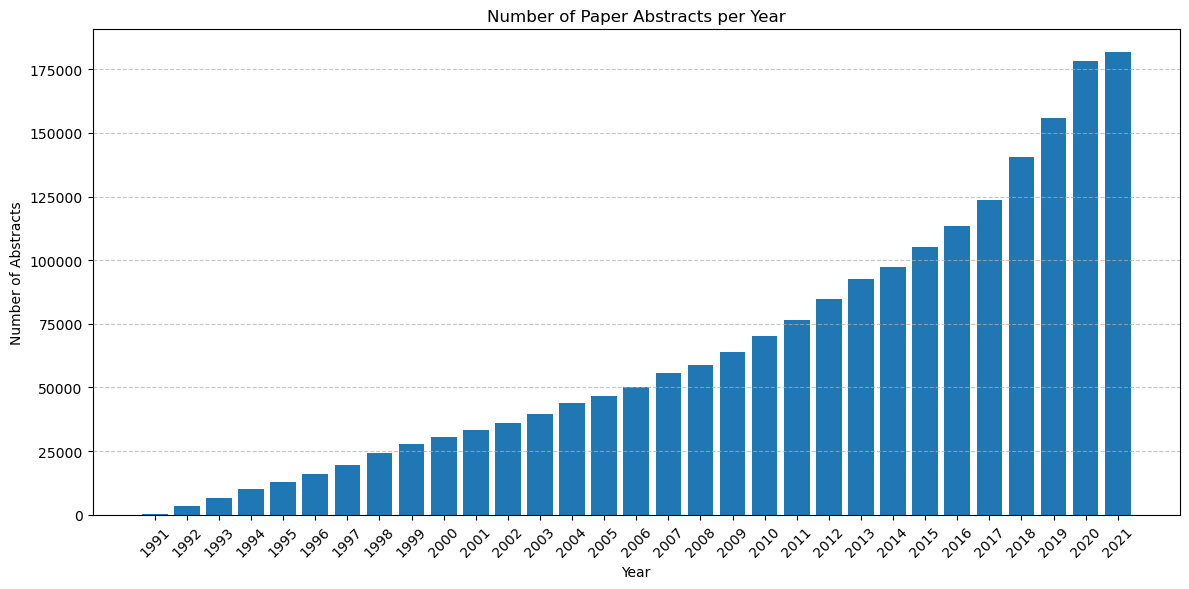

In [9]:
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel('Year')
plt.ylabel('Number of Abstracts')
plt.title('Number of Paper Abstracts per Year')
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [10]:
df.isnull().sum()

id                   0
submitter        15189
authors              0
title                0
comments        439278
journal-ref    1251755
doi             980309
abstract             0
report-no      1830583
categories           0
versions             0
year                 0
dtype: int64

In [11]:
df[df['year']<2000].sort_values('year')

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,year
1862278,hep-th/9112036,Peter Bouwknegt,"P. Bouwknegt, J. McCarthy and K. Pilch",Ground ring for the 2D NSR string,31 pages,"Nucl.Phys.B377:541-570,1992",10.1016/0550-3213(92)90301-Q,We discuss the BSRT quantization of 2D $N=1$...,None,[hep-th],[v1],1991
1862223,hep-th/9111045,V. P. Nair,"K.Lee, V.P.Nair and E.J.Weinberg",A Classical Instability of Reissner-Nordstrom ...,(10 pages),Phys.Rev.Lett. 68 (1992) 1100-1103,10.1103/PhysRevLett.68.1100,Working in the context of spontaneously brok...,None,[hep-th],"[v1, v2]",1991
1862222,hep-th/9111044,None,N. Mohammedi,Modified Black Holes in Two Dimensional Gravity,12 pages,Phys. Lett. B281 (1992) 36,10.1016/0370-2693(92)90271-5,"The $SL(2,R)/U(1)$ gauged WZWN model is modi...",None,[hep-th],[v1],1991
1862221,hep-th/9111043,Tjark Tjin,T.Tjin,An introduction to quantized Lie groups and al...,38 pages,Int.J.Mod.Phys. A7 (1992) 6175-6213,10.1142/S0217751X92002805,We give a selfcontained introduction to the ...,None,[hep-th],"[v1, v2]",1991
1862220,hep-th/9111042,None,Gerald Gilbert (umdhep.umd.edu),"""the Instability of String-Theoretic Black Holes""",8 pages,None,None,"It is demonstrated that static, charged, sph...",None,[hep-th],[v1],1991
...,...,...,...,...,...,...,...,...,...,...,...,...
1834347,hep-ph/9901247,Zhou Bang Rong,Bang-Rong Zhou,Top-quark condensate at finite temperature and...,"12 pages, latex, 1 figure, Commun. Theor. Phys...","Commun.Theor.Phys.32:425-434,1999",10.1088/0253-6102/32/3/425,The gap equation at finite temperature in th...,None,[hep-ph],[v1],1999
1834348,hep-ph/9901248,Ruben A. Alanakyan,R.A. Alanakyan,Electroweak Lepton-Lepton and Lepton-Antilepto...,"13 pages, LaTeX file, figures available upon r...",None,None,In model independent way we consider the pos...,Preprint YeRPHI-1524(24)-98,[hep-ph],[v1],1999
1834349,hep-ph/9901249,Giovanni Ridolfi,G. Ridolfi,Photoproduction of heavy quarks at HERA,"8 pages, 3 figures, LaTex with epsfig. Invited...","J.Phys.G25:1313-1319,1999",10.1088/0954-3899/25/7/307,Present status and prospects of heavy quark ...,None,[hep-ph],[v1],1999
1834336,hep-ph/9901236,D. Delepine,D. Delepine,Leptogenesis And Inflation,talk given at the International Workshop on St...,None,None,"In this talk, we studied the implication of ...",DESY 99-002,[hep-ph],[v1],1999


In [12]:
df[df['year']==2021][(~df['journal-ref'].isnull())]

/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_91470/1262542971.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['year']==2021][(~df['journal-ref'].isnull())]


,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,year
1403756,2101.00014,Juan-Felipe Mendez-Valderrama,J. F. Mendez-Valderrama and Debanjan Chowdhury,Bad metallic transport in geometrically frustr...,"37 pages, 11 figures; (v2) Final published ver...","Phys. Rev. B 103, 195111 (2021)",10.1103/PhysRevB.103.195111,We study the transport properties for a fami...,None,[cond-mat.str-el cond-mat.stat-mech],"[v1, v2]",2021
1403758,2101.00016,Artur Czerwinski,Artur Czerwinski,Quantum State Tomography of Four-Level Systems...,Accepted for publication in Acta Physica Polon...,"Acta Phys. Pol. A 139, 666 (2021)",10.12693/APhysPolA.139.666,"In this article, we investigate the problem ...",None,[quant-ph math-ph math.MP],"[v1, v2]",2021
1403759,2101.00017,Yi Pang,"Shi-Fa Guo, Hai-Shan Liu, H. Lu and Yi Pang",Large-Charge Limit of AdS Boson Stars with Mix...,"Latex, 17 pages, 7 figures, refs added, to app...",JHEP04(2021)220,10.1007/JHEP04(2021)220,It was recently shown that charged AdS boson...,None,[hep-th gr-qc],"[v1, v2]",2021
1403760,2101.00018,Sthitadhi Roy,"Sthitadhi Roy, Roderich Moessner, and Achillea...",How periodic driving stabilises and destabilis...,"6 pages, 3 figures + Supplmentary Material (2 ...","Phys. Rev. B 103, 100204 (2021)",10.1103/PhysRevB.103.L100204,Motivated by the link between Anderson local...,None,[cond-mat.dis-nn cond-mat.quant-gas cond-mat.s...,[v1],2021
1403764,2101.00022,Luuk Coopmans,"Luuk Coopmans, Shane Dooley, Ian Jubb, Kevin K...",Dynamical Phase Error in Interacting Topologic...,Accepted Version. 10 pages (including referenc...,"Phys. Rev. Research 3, 033105 (2021)",10.1103/PhysRevResearch.3.033105,A local Hamiltonian with Topological Quantum...,DIAS-STP-21-01,[cond-mat.str-el quant-ph],"[v1, v2]",2021
...,...,...,...,...,...,...,...,...,...,...,...,...
1585313,2112.15537,Stefania Scarsoglio,"Stefania Scarsoglio, Luca Ridolfi",A review of multiscale 0D-1D computational mod...,"9 pages, 4 figures, 1 table","Reviews in Cardiovascular Medicine, 22(4): 146...",10.31083/j.rcm2204150,Computational hemodynamics is becoming an in...,None,[physics.med-ph physics.flu-dyn q-bio.TO],[v1],2021
1585320,2112.15544,Luca Buoncompagni,"Luca Buoncompagni, Syed Yusha Kareem, and Fulv...",OWLOOP: A Modular API to Describe OWL Axioms i...,This version of the manuscript has been publis...,"SoftwareX, January 2022, 100952, Vol. 17, Else...",10.1016/j.softx.2021.100952,OWLOOP is an Application Programming Interfa...,None,[cs.AI cs.LO cs.SE],[v1],2021
1585328,2112.15552,Kaiyuan Yang,"Zhanghao Yu, Joshua C. Chen, Yan He, Fatima T....",Magnetoelectric Bio-Implants Powered and Progr...,This paper has been published in IEEE Journal ...,"IEEE Journal of Solid-State Circuits, 2021",10.1109/JSSC.2021.3129993,This article presents a hardware platform in...,None,[eess.SP q-bio.NC],[v1],2021
1585331,2112.15555,Tianxiao Zhang,"Yiju Yang, Tianxiao Zhang, Guanyu Li, Taejoon ...",An Unsupervised Domain Adaptation Model based ...,arXiv admin note: text overlap with arXiv:2108...,"Neurocomputing, Volume 475, 28 February 2022, ...",10.1016/j.neucom.2021.12.060,"In this paper, we propose a dual-module netw...",None,[cs.LG cs.CV],[v1],2021


In [ ]:
output_path = "./data/arxiv-abstracts-2021_with time.csv"

df.to_csv(output_path, index=False, encoding='utf-8')